<a href="https://colab.research.google.com/github/bandiamithsreenivasareddy/STRESS-DETECTION-ON-MAUS-USING-DEEP-LEARNING/blob/main/MAUS_colab_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAUS Dataset — Colab-ready processing notebook

**What this notebook does**
- Inspect the `MAUS/...` zip you uploaded.
- Show the file structure and list of subjects detected.
- Aggregate PPG and GSR signals for all subjects into single folders and combined CSVs.
- Provide example preprocessing functions (filtering, resampling, normalization).
- Provide PyTorch Dataset/DataLoader skeletons so you can run deep learning models quickly.

**Notes**
- I inspected the uploaded zip and found **no EEG files**. The dataset contains ECG, PPG, GSR (and IBI sequences). The notebook will warn and continue.
- To run this notebook in Colab: either upload the zip to the runtime (`/content`) or mount Google Drive and point `ZIP_PATH` to it.
- This notebook was auto-generated on: **2025-08-11 05:53:10 UTC**


In [ ]:
# Setup - run this first
!pip install --quiet wfdb numpy pandas scipy matplotlib torch torchvision

# Helpers
import os
import zipfile
print("Ready. Current dir:", os.getcwd())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# POINT THIS to your uploaded zip in Colab environment.
# Option A: If you uploaded dataset zip to /content, set ZIP_PATH = '/content/yourfile.zip'
# Option B: If you mounted Google Drive, set ZIP_PATH to the path in Drive.
# Option C: Use the file picker below to upload interactively.

from google.colab import files
ZIP_PATH = "C:/Users/Asus/Downloads/MAUS.zip"


if not os.path.exists(ZIP_PATH):
    print("\nZIP_PATH not found at", ZIP_PATH)
    print("You can upload the zip now (this will appear in /content).")
    uploaded = files.upload()
    # take the first uploaded file
    ZIP_PATH = list(uploaded.keys())[0]
    print("Uploaded:", ZIP_PATH)
else:
    print("Found zip at", ZIP_PATH)



ZIP_PATH not found at C:/Users/Asus/Downloads/MAUS.zip
You can upload the zip now (this will appear in /content).


Saving MAUS.zip to MAUS.zip
Uploaded: MAUS.zip


In [ ]:
# Inspect zip structure and list subjects
import zipfile, io, pandas as pd
zf = zipfile.ZipFile(ZIP_PATH)
all_paths = zf.namelist()

# show top-level folders under MAUS/Data
top = sorted([p for p in all_paths if p.startswith('MAUS/Data/')])
print("Total files in zip:", len(all_paths))

# collect subfolders under MAUS/Data/Raw_data
raw_paths = [p for p in all_paths if p.startswith('MAUS/Data/Raw_data/') and p.count('/')>=3]
subjects = sorted(list({p.split('/')[3] for p in raw_paths}))
print("Detected subjects (from MAUS/Data/Raw_data):", subjects)
print("\nCounts per subject (files):")
for s in subjects:
    cnt = sum(1 for p in all_paths if p.startswith(f'MAUS/Data/Raw_data/{s}/'))
    print(f" - {s}: {cnt} files")

# check modalities present
modalities = set()
for p in all_paths:
    lower = p.lower()
    if lower.endswith('.csv') or lower.endswith('.xlsx'):
        if 'ppg' in lower: modalities.add('PPG')
        if 'gsr' in lower: modalities.add('GSR')
        if 'ecg' in lower: modalities.add('ECG')
        if 'ibi' in lower: modalities.add('IBI')
        if 'eeg' in lower: modalities.add('EEG')
print("\nModalities found in archive:", sorted(list(modalities)))
if 'EEG' not in modalities:
    print("\nNOTE: No EEG files were detected in the archive. The notebook will process PPG/GSR/ECG/IBI only.")


Total files in zip: 1124
Detected subjects (from MAUS/Data/Raw_data): ['', '002', '003', '004', '005', '006', '008', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025']

Counts per subject (files):
 - : 0 files
 - 002: 8 files
 - 003: 8 files
 - 004: 8 files
 - 005: 8 files
 - 006: 8 files
 - 008: 8 files
 - 010: 8 files
 - 011: 8 files
 - 012: 8 files
 - 013: 8 files
 - 014: 8 files
 - 015: 8 files
 - 016: 8 files
 - 017: 8 files
 - 018: 8 files
 - 019: 8 files
 - 020: 8 files
 - 021: 8 files
 - 022: 8 files
 - 023: 8 files
 - 024: 8 files
 - 025: 8 files

Modalities found in archive: ['ECG', 'GSR', 'IBI', 'PPG']

NOTE: No EEG files were detected in the archive. The notebook will process PPG/GSR/ECG/IBI only.


In [ ]:
# Extract and aggregate PPG and GSR for all subjects
import os, zipfile, pandas as pd, numpy as np
OUTDIR = '/content/MAUS_extracted'
os.makedirs(OUTDIR, exist_ok=True)

zf = zipfile.ZipFile(ZIP_PATH)
# list relevant csv paths
ppg_paths = [p for p in zf.namelist() if p.lower().endswith('.csv') and '/raw_data/' in p.lower() and 'ppg' in p.lower()]
gsr_paths = [p for p in zf.namelist() if p.lower().endswith('.csv') and '/raw_data/' in p.lower() and 'gsr' in p.lower()]
ecg_paths = [p for p in zf.namelist() if p.lower().endswith('.csv') and '/raw_data/' in p.lower() and 'ecg' in p.lower()]

print(f'Found {len(ppg_paths)} PPG files, {len(gsr_paths)} GSR files, {len(ecg_paths)} ECG files.')

# helper to read CSVs robustly
def read_csv_from_zip(zf, path):
    with zf.open(path) as f:
        try:
            return pd.read_csv(f)
        except Exception as e:
            # try with different separators or encoding
            return pd.read_csv(f, engine='python', error_bad_lines=False)

# create per-modality folders
for md in ['ppg','gsr','ecg']:
    os.makedirs(os.path.join(OUTDIR, md), exist_ok=True)

# Save per-subject renamed CSVs and create a combined CSV per modality
def aggregate_and_save(paths, modality_name):
    rows = []
    for p in paths:
        parts = p.split('/')
        subject = parts[3]
        filename = parts[-1]
        try:
            df = read_csv_from_zip(zf, p)
        except Exception as e:
            print("Failed to read", p, e)
            continue
        # add columns for subject and original file
        df['subject'] = subject
        df['file'] = filename
        # save subject-specific copy
        outfn = os.path.join(OUTDIR, modality_name, f"{subject}__{filename}")
        df.to_csv(outfn, index=False)
        rows.append(df)
    if rows:
        combined = pd.concat(rows, ignore_index=True, sort=False)
        combined_path = os.path.join(OUTDIR, f"combined_{modality_name}.csv")
        combined.to_csv(combined_path, index=False)
        print(f"Saved combined {modality_name} -> {combined_path} (shape: {combined.shape})")
    else:
        print(f"No rows for {modality_name}")

aggregate_and_save(ppg_paths, 'ppg')
aggregate_and_save(gsr_paths, 'gsr')
aggregate_and_save(ecg_paths, 'ecg')

print("\nExtraction + aggregation complete. Files at:", OUTDIR)


Found 22 PPG files, 22 GSR files, 22 ECG files.
Saved combined ppg -> /content/MAUS_extracted/combined_ppg.csv (shape: (1689600, 8))
Saved combined gsr -> /content/MAUS_extracted/combined_gsr.csv (shape: (1689600, 8))
Saved combined ecg -> /content/MAUS_extracted/combined_ecg.csv (shape: (1689600, 8))

Extraction + aggregation complete. Files at: /content/MAUS_extracted


In [ ]:
# Preprocessing utilities (filtering, resampling, normalization)
import numpy as np
from scipy import signal
import pandas as pd

def bandpass_filter(signal_array, fs, lowcut=0.5, highcut=8.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, signal_array)

def resample_signal(sig, orig_fs, target_fs):
    # sig: 1D numpy array
    if orig_fs == target_fs:
        return sig
    duration = len(sig) / orig_fs
    num_samples = int(np.round(duration * target_fs))
    return signal.resample(sig, num_samples)

def zscore_normalize(sig):
    sig = np.array(sig, dtype=float)
    mu = np.nanmean(sig)
    sd = np.nanstd(sig)
    if sd==0: return sig-mu
    return (sig-mu)/sd

print("Preprocessing utilities ready.")


Preprocessing utilities ready.


In [ ]:
# PyTorch dataset example (structure)
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np, os

class PhysiologicalDataset(Dataset):
    def __init__(self, file_list, modality='ppg', transform=None):
        # file_list: list of file paths to numpy arrays (.npy) or CSVs
        self.files = file_list
        self.modality = modality
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        # if saved as numpy
        if path.endswith('.npy'):
            x = np.load(path)
        else:
            import pandas as pd
            df = pd.read_csv(path)
            # naive: take first numeric column
            numcols = df.select_dtypes(include='number').columns
            x = df[numcols[0]].values.astype(float)
        x = np.nan_to_num(x).astype('float32')
        if self.transform:
            x = self.transform(x)
        # placeholder label (0) — replace with real labels if available
        y = 0
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

# Example usage:
# files = ['/content/MAUS_extracted/ppg/002__inf_ppg.csv', ...]
# ds = PhysiologicalDataset(files)
# loader = DataLoader(ds, batch_size=16, shuffle=True)
print("Dataset skeleton ready.")


Dataset skeleton ready.


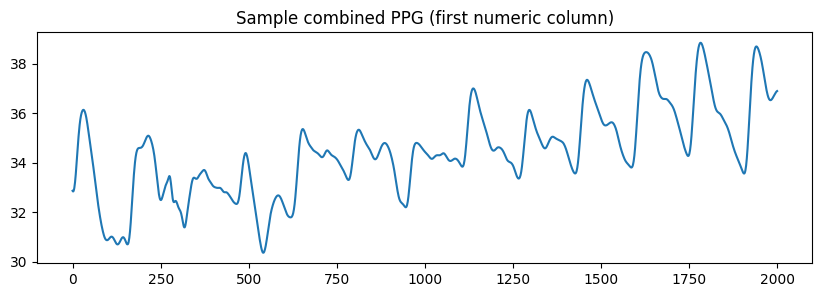

In [ ]:
# Quick visualization of a sample PPG/GSR trace
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os, glob

ppg_comb = '/content/MAUS_extracted/combined_ppg.csv'
if os.path.exists(ppg_comb):
    df = pd.read_csv(ppg_comb)
    # find a numeric column to plot
    numcols = df.select_dtypes(include='number').columns
    if len(numcols)>0:
        sample = df[numcols[0]].values[:2000]
        plt.figure(figsize=(10,3))
        plt.plot(sample)
        plt.title('Sample combined PPG (first numeric column)')
        plt.show()
    else:
        print('No numeric column in combined PPG')
else:
    print('Combined PPG not found yet. Run aggregation cell first.')



## Next steps / Suggestions
- Replace placeholder label logic with your experiment labels (e.g., task condition, stimulus, subject-level label).
- For DL models use fixed-length windows (e.g., 5s or 10s) — segment signals with overlap and save as `.npy` arrays.
- Use the `PhysiologicalDataset` skeleton to load `.npy` windows and provide labels.
- If you need EEG processing later, upload EEG channels or tell me where they are and I will add EEG-specific preprocessing (re-referencing, notch filter, bandpass for delta/theta/alpha/beta).
